- DNN(깊은 신경망), CNN(합성곱 신경망)
    - 독립적인 정보
    - 입력(x) 간의 순서나 연관성을 고려하지 않는다.
- **시계열**
    - 시간의 연속적인 흐름
    - 날씨, 주식, 문장 -> **'순서'**가 중요함!

<br>

---

# RNN(Recurrent Neural Network 순환 신경망)
입력과 출력을 시퀀스 단위로 처리하는 시퀀스(Sequence) 모델
- **순환 구조**
    - 시점1(월요일): 맑음(`x1`) 정보가 RNN에 입력됨 -> RNN: 날씨가 맑았다(`h1`) 요약본 생성
    - 시점2(화요일): 흐림(`x2`) 정보가 RNN에 입력됨 -> RNN: 새로운 정보(`x2`) + 어제의 기억(`h1`) = 어제는 맑았는데, 오늘은 흐리다(`h2`) 요약본 생성
    - 시점3(수요일): 비(`x3`) 정보가 RNN에 입력됨 -> RNN: 새로운 정보(`x3`) + 어제의 기억(`h2`) = (`h3`)
    - 반복
- **알고리즘**
    - 각 시점(timestep,`t`)에서 1. 현재-입력 + 2.과거-기억(hidden state,`ht-1`) => 3.현재의 결과물 4.다음 시점으로 넘겨줄 최신기억(`ht`)
    - `ht`: 시계열 데이터의 맥락context을 저장하는 역할을 한다.
- **장점**
    - 순서가 있는 데이터의 맥락을 학습
- **한계**
    - 기억력이 생각보다 짧다!
    - 시계열 데이터가 길어지면(ex.100단계 전의 정보), 이전 정보가 소실되거나 반대로 너무 강해져 폭주할 수 있다. -> 학습 제대로 X <br>
    _= 장기기억 의존성 문제(the problem of long-term dependency)_

RNN의 한계를 극복하기 위한 RNN 변형
#### LSTM(Long Short-Term Memory)
- 장단기 메모리
- RNN 내부에 게이트gate 복잡한 장치: 잊거나 기억할 정보를 관리


#### GRU(Gated Recurrent Unit)
- 게이트 순환 유닛
- LSTM 구조를 좀 더 단순화
- LSTM 성능은 비슷, 속도가 더 빠르다.

#### RNN의 핵심수식
- 은닉상태 계산
    - `h1 = tanh(w\*ht-1 + w\*ht - b*h)`   (bh: 편향)
- 출력


# 예제1: 주식

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/pia222sk20/python/main/data/time_data_train.csv'

df = pd.read_csv(url)
df.head()


,Date,Open,High,Low,Volume,Close
0,2015-12-16,120,123,118,13181000,123
1,2015-12-17,124,126,122,17284900,123
2,2015-12-18,121,122,118,17948100,118
3,2015-12-21,120,120,116,11670000,117
4,2015-12-22,117,117,115,9689000,116


In [ ]:
# 전체 데이터셋 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 967 entries, 0 to 966
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    967 non-null    object
 1   Open    967 non-null    int64 
 2   High    967 non-null    int64 
 3   Low     967 non-null    int64 
 4   Volume  967 non-null    int64 
 5   Close   967 non-null    int64 
dtypes: int64(5), object(1)
memory usage: 45.5+ KB


In [28]:
# EDA
import numpy as np
from torch.utils.data import  Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch

class StockDataSet(Dataset):
    def __init__(self):
        url = 'https://raw.githubusercontent.com/pia222sk20/python/main/data/time_data_train.csv'
        self.csv = pd.read_csv(url)
        data = self.csv.iloc[:,1:-1].values
        label = self.csv.iloc[:,-1].values.reshape(-1,1)
        # X: Date,Close 제외, 값만 추출  # 정규화    
        self.data = StandardScaler().fit_transform(data) 
        # 정답이 숫자가 크다면, 정규화가 학습에 도움이 된다. (입력을 정규화해서 작아짐 -> 작은 값으로 큰 출력을 만들어야 함 -> loss가 커진다.)
        self.label = StandardScaler().fit_transform(label)
        self.data = torch.Tensor(self.data)
        self.label = torch.Tensor(self.label) 

    def __len__(self):
        return len(self.data) - 30 #사용가능한 배치 수
    def __getitem__(self, index):
        data = self.data[index: index + 30] # 입력 구간 (30일치 데이터)
        label = self.label[index + 30]  # 예측 대상 (30일 뒤 데이터), 과거 30일치 데이터를 보고 30일 '다음 날' 값을 예측함
        return data, label

In [29]:
# 데이터 확인
dataset = StockDataSet()
data, label = next(iter(dataset))
data.size(), label.size()

(torch.Size([30, 4]), torch.Size([1]))

In [30]:
import torch.nn as nn

class StockRNN(nn.Module):
    def __init__(self):
        super(StockRNN, self).__init__()
        # (30일, 배치 16개, 각 입력의 특성 4개) batch_first=False
        # (배치 16개, 30일, 각 입력의 특성 4개) batch_first=True
        self.rnn = nn.RNN(input_size=4, hidden_size=8, num_layers=5, batch_first=True)
        # (batch_size, sequence_length, feature_dim)=(16,30,3) -> 출력 (batch, sequence_length, hidden_size)=(16, 30, 8)
        self.fc1 = nn.Linear(30*8,64)
        self.fc2 = nn.Linear(64,1) #1: 다음날 종가
        self.relu = nn.ReLU()

    def forward(self,x,ho):
        # x:입력데이터(16, 30, 4), ho:초기 은닉 상태(num_layers, batch, hidden_size)=(5,16,8)
        # 출력 x: 모든 시점에 대한 hidden output을 담고 있어야 한다. (16, 30, 8)
        # 출력 hn: 최종 은닉 상태, 각 layer의 마지막 timestemp-hidden state (5,16,8)
        x, hn = self.rnn(x,ho)
        # mlp 입력으로 사용될 수 있도록 모양 변경
        x = torch.reshape(x, (x.shape[0],-1))
        # mlp
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        # 예측한 종가 1차원 벡터
        out = torch.flatten(x) 
        return out
        

In [31]:
rnn = StockRNN()
sample_data = torch.randn(16,30,4)
# 초기 hidden state 값 (num_layer, batch_size, hidden_size)
ho = torch.zeros(5,16,8)
out= rnn(sample_data, ho)
out


tensor([-0.0900, -0.0872, -0.0961, -0.1124, -0.0976, -0.0920, -0.0877, -0.0901,
        -0.0874, -0.0831, -0.1062, -0.1140, -0.0987, -0.1226, -0.0930, -0.0898],
       grad_fn=<ViewBackward0>)

In [ ]:
from torch.optim import Adam
from torch.utils.data.dataloader import DataLoader

device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = StockRNN().to(device)
dataset = StockDataSet()
loader = DataLoader(dataset, batch_size=16) # drop_last=True-> 마지막 불완전 배치 버리기-> batch_size 고정!
optim = Adam(model.parameters(), lr=1e-3)

In [ ]:
import tqdm as tqdm
# criterian = nn.MSELoss() -> loss = criterian(pred, label)

for epoch in range(200):
    loop=tqdm.tqdm(loader)
    for data, label in loop:
        optim.zero_grad()
        # 초기 은닉 상태
        batch_size = data.size(0)
        ho = torch.zeros(5,batch_size,8).to(device)
        # 모델의 예측값
        pred = model(data.to(device), ho)
        # 회귀 -> 손실값
        loss = nn.MSELoss()(pred, label.to(device))
        loss.backward()
        optim.step()

        loop.set_description(f'epoch: {epoch+1} | loss: {loss.item()}')

torch.save(model.state_dict(), './rnn.path')

  0%|          | 0/58 [00:00<?, ?it/s]c:\python_src\.venv\Lib\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([16, 1])) that is different to the input size (torch.Size([16])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
epoch: 1 | loss: 0.03044675663113594: 100%|██████████| 58/58 [00:05<00:00, 10.86it/s] 
epoch: 2 | loss: 1.0404653549194336: 100%|██████████| 58/58 [00:07<00:00,  8.10it/s]   
epoch: 3 | loss: 0.3825114667415619: 100%|██████████| 58/58 [00:08<00:00,  7.06it/s]   
epoch: 4 | loss: 0.26488572359085083: 100%|██████████| 58/58 [00:05<00:00, 10.97it/s]  
epoch: 5 | loss: 0.3349275290966034: 100%|██████████| 58/58 [00:04<00:00, 11.93it/s]   
epoch: 6 | loss: 0.3840489983558655: 100%|██████████| 58/58 [00:05<00:00, 10.88it/s]   
epoch: 7 | loss: 0.3210890293121338: 100%|██████████| 58/58 [00:08<00:00,  7.09it/s]   
epoc

In [49]:
# 모델 성능 평가
import matplotlib.pyplot as plt

loader = DataLoader(dataset, batch_size=1)
preds = []
total_loss = 0

with torch.no_grad():
    model.load_state_dict(torch.load('rnn.path', map_location=device))
    for data, label in loader:
        batch_size = data.size(0)
        ho = torch.zeros(5,batch_size,8).to(device)
        # 모델의 예측값
        pred = model(data.to(device), ho)
        preds.append(pred.item())
        # 회귀 -> 손실값
        loss = nn.MSELoss()(pred, label.to(device))
        total_loss += ( loss.item() / len(loader) )
print(f'total_loss: {total_loss:.4f}')
        

c:\python_src\.venv\Lib\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


total_loss: 0.0320


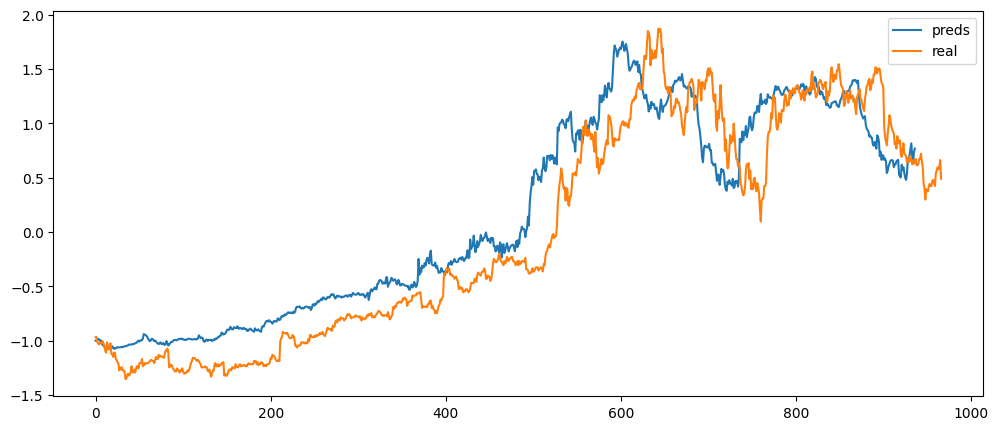

In [51]:
plt.figure(figsize=(12,5))
plt.plot(preds, label='preds')
plt.plot(dataset.label, label='real')
plt.legend()
plt.show()